In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(10)
n = 250

In [3]:
students = pd.DataFrame({
    "Student_ID": np.arange(1, n+1),
    "Name": ["Std_" + str(i) for i in range(1, n+1)],
    "Gender": np.random.choice(["Male", "Female"], n),
    "Department": np.random.choice(["CSE", "IT", "ECE"], n),
    "Year": np.random.choice(["1st", "2nd", "3rd"], n),
})


In [6]:
#Marks (realistic)
students["Maths"] = np.random.normal(70, 15, n).astype(int)
students["Science"] = np.random.normal(65, 15, n).astype(int)
students["English"] = np.random.normal(75, 10, n).astype(int)


In [7]:

# Fix limits
students["Maths"] = students["Maths"].clip(35, 100)
students["Science"] = students["Science"].clip(35, 100)
students["English"] = students["English"].clip(35, 100)

In [8]:
# Attendance & Internal
students["Attendance"] = np.random.randint(60, 100, n)
students["Internal_Marks"] = np.random.randint(5, 25, n)

In [9]:
print("Missing Values:\n", students.isnull().sum())

Missing Values:
 Student_ID        0
Name              0
Gender            0
Department        0
Year              0
Maths             0
Science           0
English           0
Attendance        0
Internal_Marks    0
dtype: int64


In [11]:
students["Total"] = students["Maths"] + students["Science"] + students["English"]
students["Average"] = students["Total"] / 3



In [12]:
def get_grade(avg):
    if avg >= 80:
        return "A"
    elif avg >= 60:
        return "B"
    elif avg >= 40:
        return "C"
    else:
        return "Fail"


In [25]:
students["Grade"] = students["Average"].apply(get_grade)


In [24]:
print("\nDataset Info:")
print(students.info())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      250 non-null    int64  
 1   Name            250 non-null    object 
 2   Gender          250 non-null    object 
 3   Department      250 non-null    object 
 4   Year            250 non-null    object 
 5   Maths           250 non-null    int64  
 6   Science         250 non-null    int64  
 7   English         250 non-null    int64  
 8   Attendance      250 non-null    int64  
 9   Internal_Marks  250 non-null    int64  
 10  Total           250 non-null    int64  
 11  Average         250 non-null    float64
 12  Grade           250 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 25.5+ KB
None


In [23]:
print("\nStatistics:")
print(students.describe())



Statistics:
       Student_ID       Maths     Science     English  Attendance  \
count  250.000000  250.000000  250.000000  250.000000  250.000000   
mean   125.500000   69.432000   62.952000   74.196000   79.068000   
std     72.312977   13.083811   13.941274    9.631649   11.478257   
min      1.000000   35.000000   35.000000   41.000000   60.000000   
25%     63.250000   60.000000   53.000000   69.000000   69.000000   
50%    125.500000   69.000000   63.000000   74.000000   78.000000   
75%    187.750000   78.000000   72.000000   80.750000   89.750000   
max    250.000000  100.000000   98.000000  100.000000   99.000000   

       Internal_Marks       Total     Average  
count      250.000000  250.000000  250.000000  
mean        14.684000  206.580000   68.860000  
std          5.863931   20.775033    6.925011  
min          5.000000  154.000000   51.333333  
25%         10.000000  193.000000   64.333333  
50%         15.000000  208.000000   69.333333  
75%         20.000000  220.00

In [22]:
print("\nTop 5 Students:")
print(students.sort_values(by="Total", ascending=False).head())



Top 5 Students:
     Student_ID     Name  Gender Department Year  Maths  Science  English  \
126         127  Std_127  Female         IT  1st     91       96       90   
130         131  Std_131    Male        CSE  2nd     89       97       86   
39           40   Std_40  Female        CSE  2nd     91       81       94   
114         115  Std_115  Female        CSE  2nd    100       76       86   
21           22   Std_22  Female        ECE  2nd     82       93       77   

     Attendance  Internal_Marks  Total    Average Grade  
126          65              12    277  92.333333     A  
130          95              16    272  90.666667     A  
39           90              14    266  88.666667     A  
114          79              22    262  87.333333     A  
21           68              23    252  84.000000     A  


In [21]:
print("\nFail Students:")
print(students[students["Grade"] == "Fail"])



Fail Students:
Empty DataFrame
Columns: [Student_ID, Name, Gender, Department, Year, Maths, Science, English, Attendance, Internal_Marks, Total, Average, Grade]
Index: []


In [20]:
print("\nDepartment-wise Average:")
print(students.groupby("Department")["Average"].mean())


Department-wise Average:
Department
CSE    69.135802
ECE    69.222222
IT     68.203252
Name: Average, dtype: float64


In [19]:
print("\nGender-wise Average:")
print(students.groupby("Gender")["Average"].mean())


Gender-wise Average:
Gender
Female    69.758333
Male      68.030769
Name: Average, dtype: float64


In [18]:
print("\nYear-wise Average:")
print(students.groupby("Year")["Average"].mean())



Year-wise Average:
Year
1st    69.808889
2nd    69.064103
3rd    67.962199
Name: Average, dtype: float64


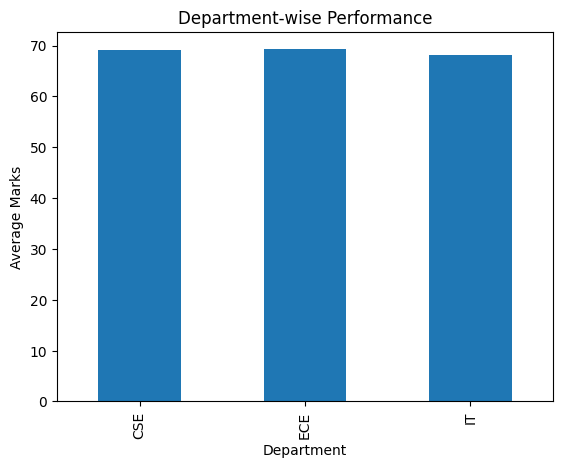

In [17]:
# Bar Chart
students.groupby("Department")["Average"].mean().plot(kind="bar")
plt.title("Department-wise Performance")
plt.xlabel("Department")
plt.ylabel("Average Marks")
plt.show()


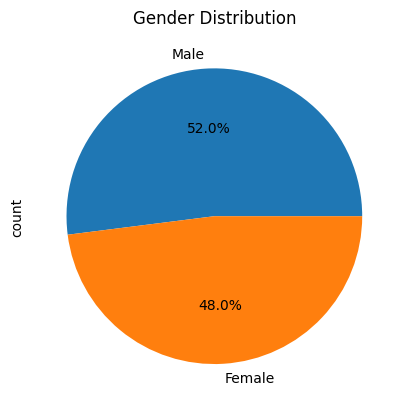

In [16]:
# Pie Chart
students["Gender"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()


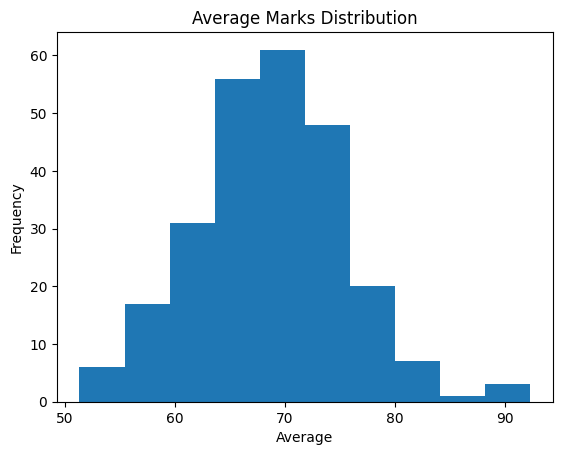

In [15]:
# Histogram
plt.hist(students["Average"])
plt.title("Average Marks Distribution")
plt.xlabel("Average")
plt.ylabel("Frequency")
plt.show()

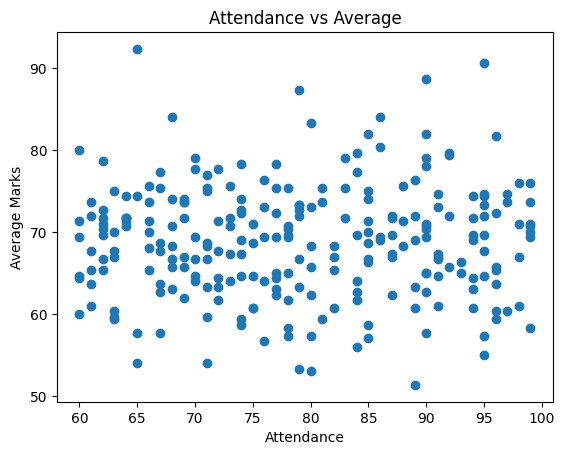

In [14]:
# Scatter Plot
plt.scatter(students["Attendance"], students["Average"])
plt.title("Attendance vs Average")
plt.xlabel("Attendance")
plt.ylabel("Average Marks")
plt.show()